In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

In [ ]:
print(np.__version__)
print(pd.__version__)
print(sklearn.__version__)

2.0.2
2.2.2
1.6.1


In [2]:
data=pd.read_csv('/content/Bengaluru_House_Data.csv')

In [3]:
data.head(5)

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [4]:
data.shape

(13320, 9)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [6]:
data['area_type'].value_counts()

,count
area_type,
Super built-up Area,8790
Built-up Area,2418
Plot Area,2025
Carpet Area,87


In [7]:
for column in data.columns:
    print(f"Value counts for column '{column}':")
    display(data[column].value_counts())
    print("\n" + "-"*50 + "\n")

Value counts for column 'area_type':


,count
area_type,
Super built-up Area,8790
Built-up Area,2418
Plot Area,2025
Carpet Area,87



--------------------------------------------------

Value counts for column 'availability':


,count
availability,
Ready To Move,10581
18-Dec,307
18-May,295
18-Apr,271
18-Aug,200
...,...
16-Oct,1
17-Jan,1
16-Nov,1



--------------------------------------------------

Value counts for column 'location':


...


--------------------------------------------------

Value counts for column 'balcony':


,count
balcony,
2.0,5113
1.0,4897
3.0,1672
0.0,1029



--------------------------------------------------

Value counts for column 'price':


,count
price,
75.00,310
65.00,302
55.00,275
60.00,270
45.00,240
...,...
219.00,1
32.93,1
988.00,1



--------------------------------------------------



In [8]:
data.isna().sum()

,0
area_type,0
availability,0
location,1
size,16
society,5502
total_sqft,0
bath,73
balcony,609
price,0


In [9]:
data.drop(columns=['area_type','availability','society','balcony'],inplace=True)

In [10]:
data.describe()

,bath,price
count,13247.000000,13320.000000
mean,2.692610,112.565627
std,1.341458,148.971674
min,1.000000,8.000000
25%,2.000000,50.000000
50%,2.000000,72.000000
75%,3.000000,120.000000
max,40.000000,3600.000000


In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    13319 non-null  object 
 1   size        13304 non-null  object 
 2   total_sqft  13320 non-null  object 
 3   bath        13247 non-null  float64
 4   price       13320 non-null  float64
dtypes: float64(2), object(3)
memory usage: 520.4+ KB


In [12]:
data['location'].value_counts()

,count
location,
Whitefield,540
Sarjapur Road,399
Electronic City,302
Kanakpura Road,273
Thanisandra,234
...,...
Park View Layout,1
Xavier Layout,1
Air View Colony,1


In [13]:
data['location']=data['location'].fillna('Sarjapur Road')

In [14]:
data['size'].value_counts()

,count
size,
2 BHK,5199
3 BHK,4310
4 Bedroom,826
4 BHK,591
3 Bedroom,547
1 BHK,538
2 Bedroom,329
5 Bedroom,297
6 Bedroom,191


In [15]:
data['size']=data['size'].fillna('2 BHK')

In [16]:
data['bath']=data['bath'].fillna(data['bath'].median())

In [17]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    13320 non-null  object 
 1   size        13320 non-null  object 
 2   total_sqft  13320 non-null  object 
 3   bath        13320 non-null  float64
 4   price       13320 non-null  float64
dtypes: float64(2), object(3)
memory usage: 520.4+ KB


## size column e 2 BHK,4 Bedroom emon problem chilo.. tai 2/4 emon numerical number ke alada kore alada ekta colum banabo

In [18]:
data['bhk']=data['size'].str.split().str.get(0).astype(int)

In [19]:
data.head(5)

,location,size,total_sqft,bath,price,bhk
0,Electronic City Phase II,2 BHK,1056,2.0,39.07,2
1,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00,4
2,Uttarahalli,3 BHK,1440,2.0,62.00,3
3,Lingadheeranahalli,3 BHK,1521,3.0,95.00,3
4,Kothanur,2 BHK,1200,2.0,51.00,2


In [20]:
data[data.bhk>20]

,location,size,total_sqft,bath,price,bhk
1718,2Electronic City Phase II,27 BHK,8000,27.0,230.0,27
4684,Munnekollal,43 Bedroom,2400,40.0,660.0,43


In [21]:
data['total_sqft'].unique()

array(['1056', '2600', '1440', ..., '1133 - 1384', '774', '4689'],
      dtype=object)

## converting Range value to floats

In [22]:
def convert_sqft_to_num(x):
    try:
        tokens = x.split('-')
        if len(tokens) == 2:
            return (float(tokens[0]) + float(tokens[1])) / 2
        return float(x)
    except:
        return None

data['total_sqft'] = data['total_sqft'].apply(convert_sqft_to_num)

In [23]:
data.head()

,location,size,total_sqft,bath,price,bhk
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3
4,Kothanur,2 BHK,1200.0,2.0,51.00,2


## price per sq feet

In [24]:
data['price_per_sqft']=data['price']*100000/data['total_sqft']

In [25]:
data.head(5)

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699.810606
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615.384615
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305.555556
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245.890861
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250.000000


In [26]:
data['location'].value_counts()

,count
location,
Whitefield,540
Sarjapur Road,399
Electronic City,302
Kanakpura Road,273
Thanisandra,234
...,...
1 Giri Nagar,1
ITI Employees Layout,1
Subramanyanagar,1


## removing extra spaces or hidden characters from beginning or end of each location name

In [27]:
data['location']=data['location'].apply(lambda x:x.strip())

In [28]:
location_count=data['location'].value_counts()
location_count

,count
location,
Whitefield,541
Sarjapur Road,399
Electronic City,304
Kanakpura Road,273
Thanisandra,237
...,...
Prasanti Nagar,1
"Banasawadi,",1
Sunkan palya,1


In [29]:
location_count_less_10=location_count[location_count<=10]
location_count_less_10

,count
location,
Sector 1 HSR Layout,10
Nagadevanahalli,10
Dairy Circle,10
1st Block Koramangala,10
Naganathapura,10
...,...
Prasanti Nagar,1
"Banasawadi,",1
Sunkan palya,1


In [30]:
data['location']=data['location'].apply(lambda x:'other' if x in location_count_less_10 else x)

In [31]:
data['location'].value_counts()

,count
location,
other,2886
Whitefield,541
Sarjapur Road,399
Electronic City,304
Kanakpura Road,273
...,...
Tindlu,11
Marsur,11
2nd Phase Judicial Layout,11


## Outlier detection and removal

In [32]:
data.describe()

,total_sqft,bath,price,bhk,price_per_sqft
count,13274.000000,13320.000000,13320.000000,13320.000000,1.327400e+04
mean,1559.626694,2.688814,112.565627,2.802778,7.907501e+03
std,1238.405258,1.338754,148.971674,1.294496,1.064296e+05
min,1.000000,1.000000,8.000000,1.000000,2.678298e+02
25%,1100.000000,2.000000,50.000000,2.000000,4.266865e+03
50%,1276.000000,2.000000,72.000000,3.000000,5.434306e+03
75%,1680.000000,3.000000,120.000000,3.000000,7.311746e+03
max,52272.000000,40.000000,3600.000000,43.000000,1.200000e+07


In [33]:
data=data[((data['total_sqft']/data['bhk'])>=300)]

In [34]:
data.describe()

,total_sqft,bath,price,bhk,price_per_sqft
count,12530.000000,12530.000000,12530.000000,12530.000000,12530.000000
mean,1594.564544,2.559537,111.382401,2.650838,6303.979357
std,1261.271296,1.077938,152.077329,0.976678,4162.237981
min,300.000000,1.000000,8.440000,1.000000,267.829813
25%,1116.000000,2.000000,49.000000,2.000000,4210.526316
50%,1300.000000,2.000000,70.000000,3.000000,5294.117647
75%,1700.000000,3.000000,115.000000,3.000000,6916.666667
max,52272.000000,16.000000,3600.000000,16.000000,176470.588235


In [35]:
data.price_per_sqft.describe()

,price_per_sqft
count,12530.000000
mean,6303.979357
std,4162.237981
min,267.829813
25%,4210.526316
50%,5294.117647
75%,6916.666667
max,176470.588235


In [36]:
def remove_outliers_sqft(df):
  df_output=pd.DataFrame()
  for key,subdf in df.groupby('location'):
    m=np.mean(subdf.price_per_sqft)
    st=np.std(subdf.price_per_sqft)

    gen_df=subdf[((subdf.price_per_sqft>(m-st))&(subdf.price_per_sqft<=(m+st)))]
    df_output=pd.concat([df_output,gen_df],ignore_index=True)
  return df_output

data=remove_outliers_sqft(data)
data.describe()

,total_sqft,bath,price,bhk,price_per_sqft
count,10301.000000,10301.000000,10301.000000,10301.000000,10301.000000
mean,1508.440608,2.471702,91.286372,2.574896,5659.062876
std,880.694214,0.979449,86.342786,0.897649,2265.774749
min,300.000000,1.000000,10.000000,1.000000,1250.000000
25%,1110.000000,2.000000,49.000000,2.000000,4244.897959
50%,1286.000000,2.000000,67.000000,2.000000,5175.600739
75%,1650.000000,3.000000,100.000000,3.000000,6428.571429
max,30400.000000,16.000000,2200.000000,16.000000,24509.803922


In [37]:
data.drop(columns=['size','price_per_sqft'],inplace=True)

In [38]:
data.head(5)

,location,total_sqft,bath,price,bhk
0,1st Block Jayanagar,2850.0,4.0,428.0,4
1,1st Block Jayanagar,1630.0,3.0,194.0,3
2,1st Block Jayanagar,1875.0,2.0,235.0,3
3,1st Block Jayanagar,1200.0,2.0,130.0,3
4,1st Block Jayanagar,1235.0,2.0,148.0,2


In [39]:
X=data.drop(columns=['price'])
y=data['price']

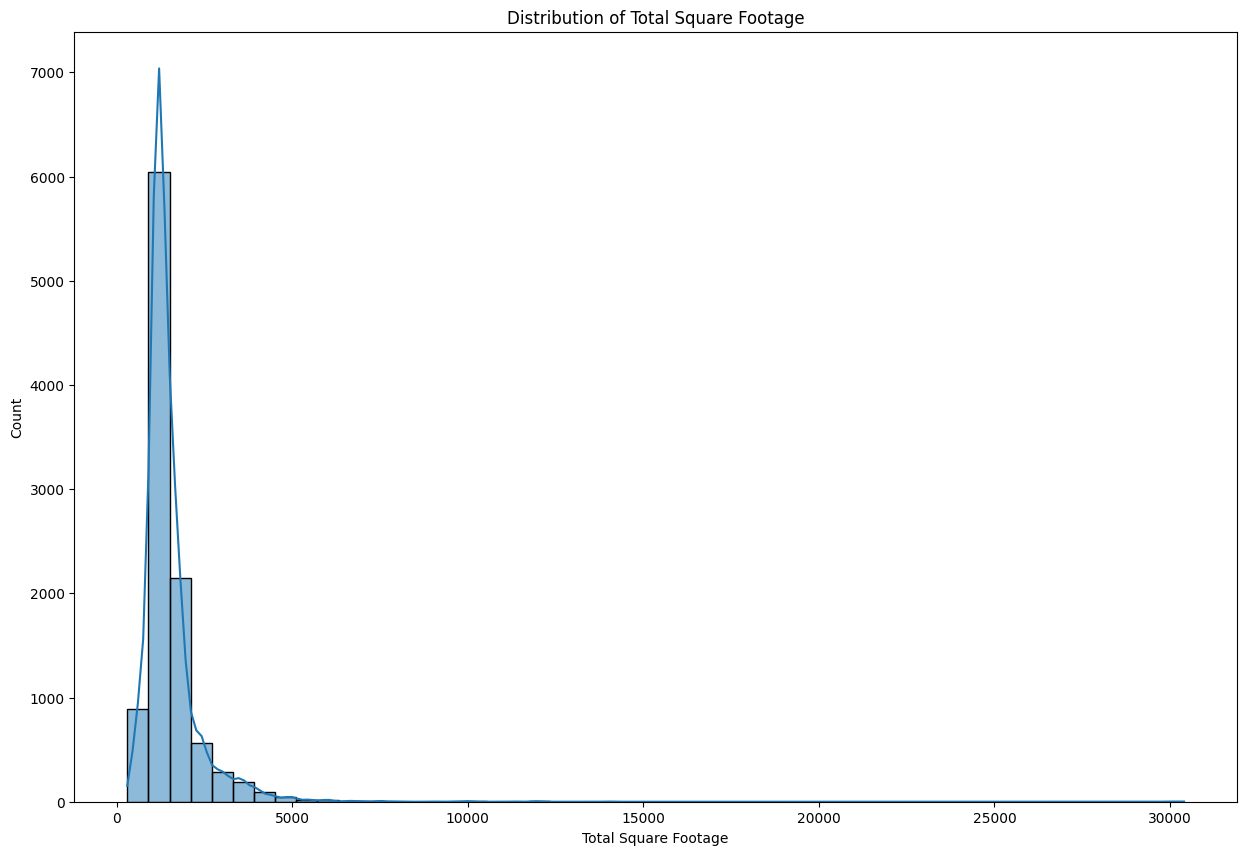

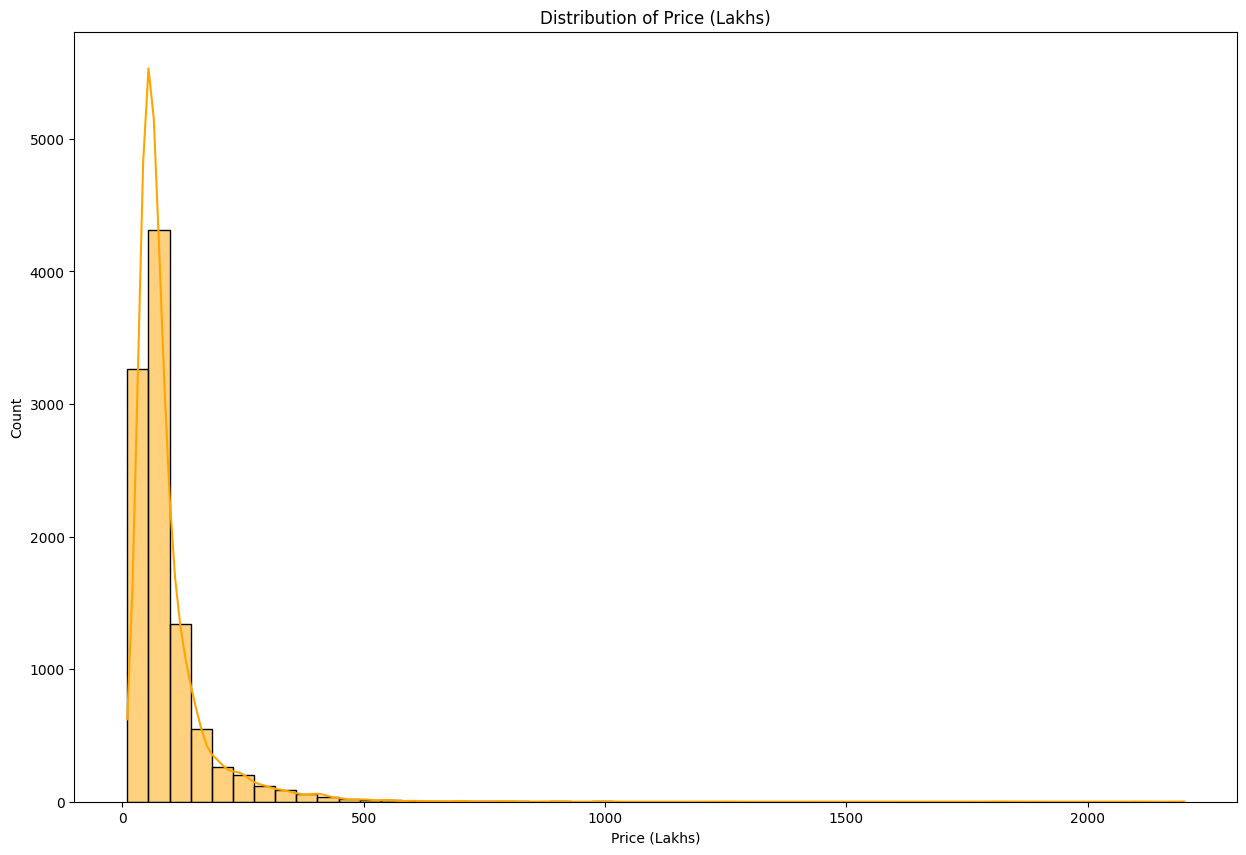

/tmp/ipykernel_1734/1293171392.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='bath', data=data, palette='viridis')


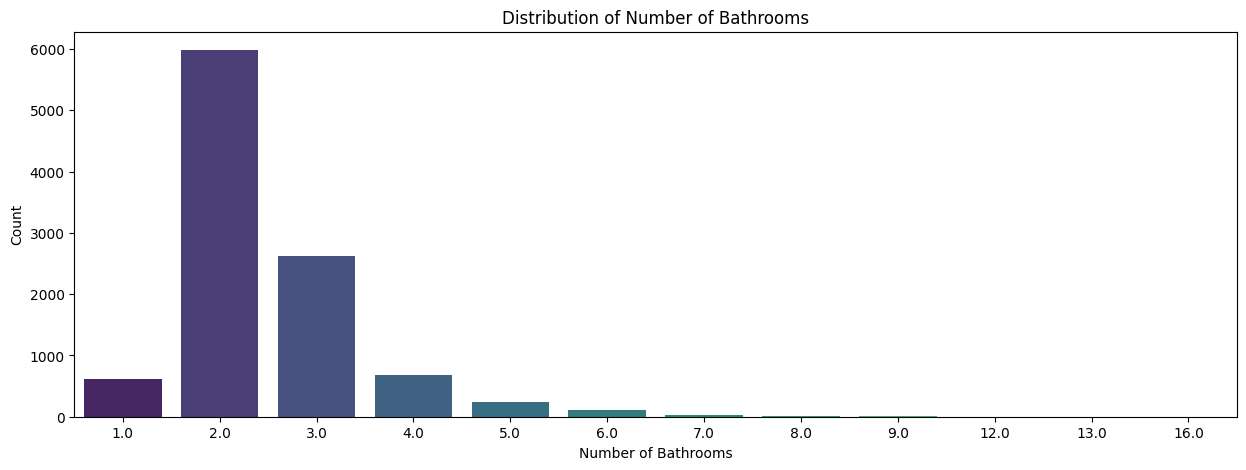

/tmp/ipykernel_1734/1293171392.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='bhk', data=data, palette='magma')


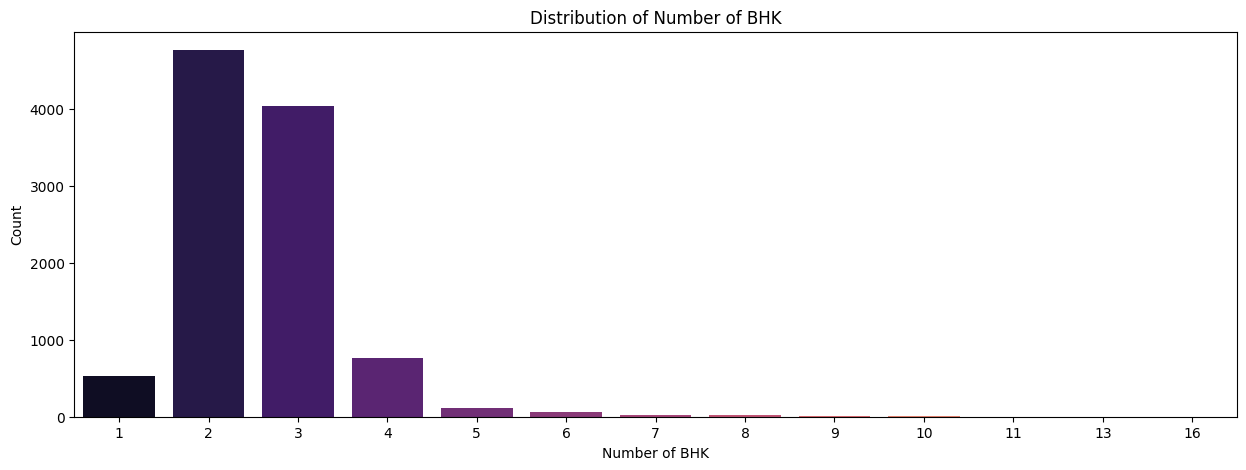

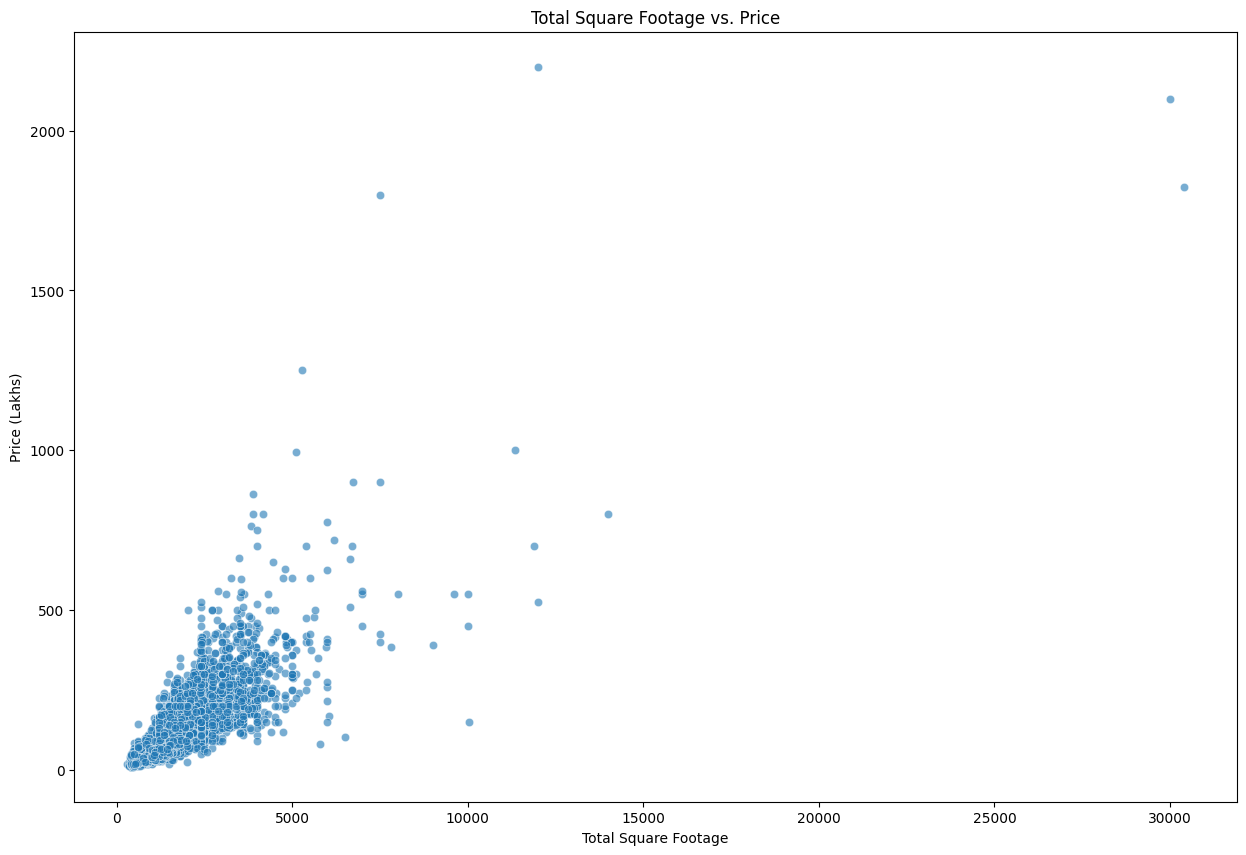

/tmp/ipykernel_1734/1293171392.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='bhk', y='price', data=data, palette='coolwarm')


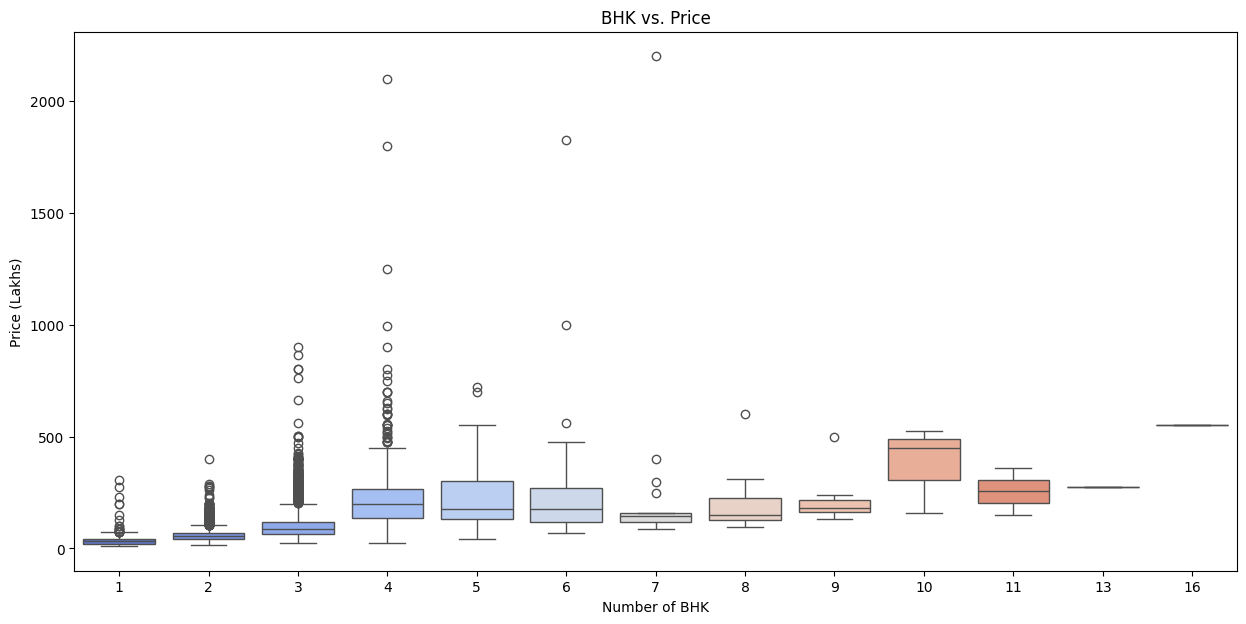

/tmp/ipykernel_1734/1293171392.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='bath', y='price', data=data, palette='cubehelix')


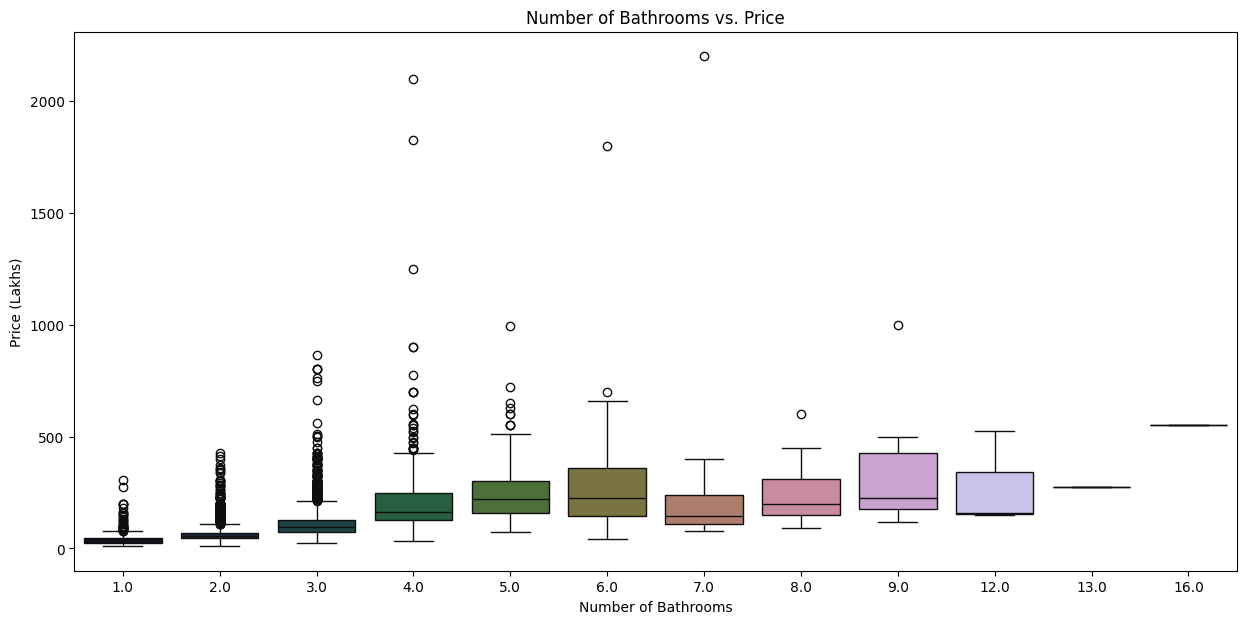

/tmp/ipykernel_1734/1293171392.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='location', y='price', data=data[data['location'].isin(top_locations)], palette='Spectral')


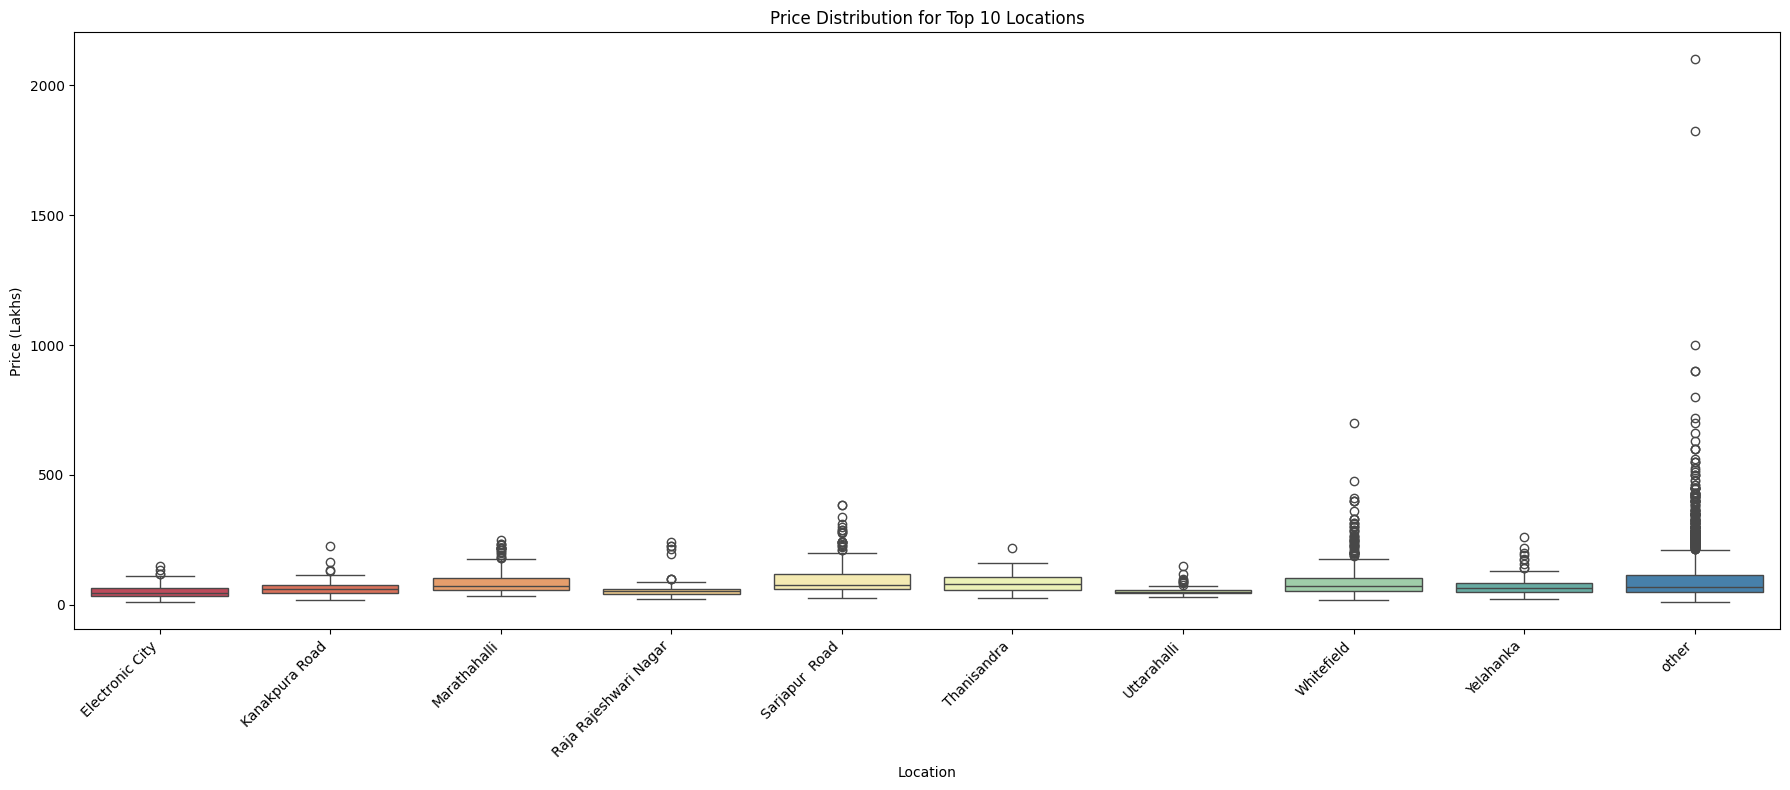

In [42]:
plt.figure(figsize=(15, 10))
sns.histplot(data['total_sqft'], kde=True, bins=50)
plt.title('Distribution of Total Square Footage')
plt.xlabel('Total Square Footage')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(15, 10))
sns.histplot(data['price'], kde=True, bins=50, color='orange')
plt.title('Distribution of Price (Lakhs)')
plt.xlabel('Price (Lakhs)')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(15, 5))
sns.countplot(x='bath', data=data, palette='viridis')
plt.title('Distribution of Number of Bathrooms')
plt.xlabel('Number of Bathrooms')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(15, 5))
sns.countplot(x='bhk', data=data, palette='magma')
plt.title('Distribution of Number of BHK')
plt.xlabel('Number of BHK')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(15, 10))
sns.scatterplot(x='total_sqft', y='price', data=data, alpha=0.6)
plt.title('Total Square Footage vs. Price')
plt.xlabel('Total Square Footage')
plt.ylabel('Price (Lakhs)')
plt.show()

plt.figure(figsize=(15, 7))
sns.boxplot(x='bhk', y='price', data=data, palette='coolwarm')
plt.title('BHK vs. Price')
plt.xlabel('Number of BHK')
plt.ylabel('Price (Lakhs)')
plt.show()

plt.figure(figsize=(15, 7))
sns.boxplot(x='bath', y='price', data=data, palette='cubehelix')
plt.title('Number of Bathrooms vs. Price')
plt.xlabel('Number of Bathrooms')
plt.ylabel('Price (Lakhs)')
plt.show()

# Visualize price distribution for top locations
top_locations = data['location'].value_counts().head(10).index
plt.figure(figsize=(18, 8))
sns.boxplot(x='location', y='price', data=data[data['location'].isin(top_locations)], palette='Spectral')
plt.title('Price Distribution for Top 10 Locations')
plt.xlabel('Location')
plt.ylabel('Price (Lakhs)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Correlation Analysis

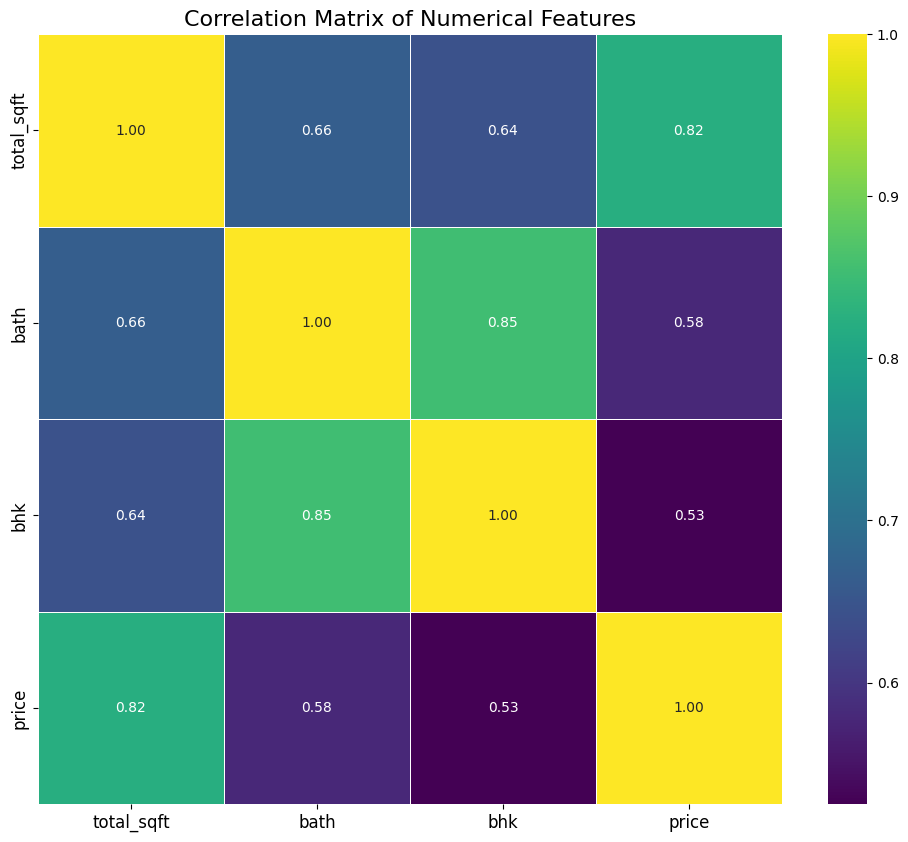

In [44]:
plt.figure(figsize=(12, 10))
sns.heatmap(data[['total_sqft', 'bath', 'bhk', 'price']].corr(), annot=True, cmap='viridis', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Numerical Features', fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,Lasso,Ridge
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.pipeline import make_pipeline


In [41]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [45]:
X_train.head()

,location,total_sqft,bath,bhk
9008,other,1365.0,3.0,3
9430,other,1804.0,3.0,3
8899,other,3400.0,6.0,4
841,Bannerghatta Road,1215.0,2.0,2
2124,Electronic City,1140.0,2.0,2


In [46]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['total_sqft', 'bath', 'bhk']),
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['location'])
    ])

In [47]:
pipe = make_pipeline(preprocessor, LinearRegression())
pipe.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['total_sqft', 'bath',
                                                   'bhk']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['location'])])),
                ('linearregression', LinearRegression())])

In [48]:
y_pred = pipe.predict(X_test)

In [49]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"R-squared: {r2:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")

R-squared: 0.82
Mean Absolute Error (MAE): 20.09
Mean Squared Error (MSE): 1142.72


In [50]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.pipeline import make_pipeline

models = {
    'Linear Regression': LinearRegression(),
    'Lasso': Lasso(),
    'Ridge': Ridge(),
    'Decision Tree Regressor': DecisionTreeRegressor(random_state=42),
    'Random Forest Regressor': RandomForestRegressor(random_state=42),
    'Gradient Boosting Regressor': GradientBoostingRegressor(random_state=42)
}

results = {}

print("\n--- Model Performance Comparison ---\n")

for name, model in models.items():
    print(f"Training {name}...")
    pipeline = make_pipeline(preprocessor, model)
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)

    results[name] = {'R-squared': r2, 'MAE': mae, 'MSE': mse}

    print(f"{name}:\n  R-squared: {r2:.2f}\n  MAE: {mae:.2f}\n  MSE: {mse:.2f}\n")

print("--- Summary of Results ---")
for name, metrics in results.items():
    print(f"{name}: R-squared={metrics['R-squared']:.2f}, MAE={metrics['MAE']:.2f}, MSE={metrics['MSE']:.2f}")



--- Model Performance Comparison ---

Training Linear Regression...
Linear Regression:
  R-squared: 0.82
  MAE: 20.09
  MSE: 1142.72

Training Lasso...
Lasso:
  R-squared: 0.69
  MAE: 25.42
  MSE: 2027.63

Training Ridge...
Ridge:
  R-squared: 0.83
  MAE: 20.04
  MSE: 1134.37

Training Decision Tree Regressor...
Decision Tree Regressor:
  R-squared: 0.78
  MAE: 19.45
  MSE: 1406.90

Training Random Forest Regressor...
Random Forest Regressor:
  R-squared: 0.84
  MAE: 17.74
  MSE: 1070.55

Training Gradient Boosting Regressor...
Gradient Boosting Regressor:
  R-squared: 0.81
  MAE: 21.01
  MSE: 1220.64

--- Summary of Results ---
Linear Regression: R-squared=0.82, MAE=20.09, MSE=1142.72
Lasso: R-squared=0.69, MAE=25.42, MSE=2027.63
Ridge: R-squared=0.83, MAE=20.04, MSE=1134.37
Decision Tree Regressor: R-squared=0.78, MAE=19.45, MSE=1406.90
Random Forest Regressor: R-squared=0.84, MAE=17.74, MSE=1070.55
Gradient Boosting Regressor: R-squared=0.81, MAE=21.01, MSE=1220.64


In [52]:
from sklearn.model_selection import GridSearchCV

# Identify the best model (Random Forest Regressor)
best_model_name = 'Random Forest Regressor'
best_model = models[best_model_name]

print(f"\n--- Fine-tuning {best_model_name} ---\n")

# Define a reduced parameter grid for Random Forest Regressor for faster execution
param_grid = {
    'randomforestregressor__n_estimators': [100, 200], # Reduced number of trees
    'randomforestregressor__max_features': ['sqrt'], # Focused on 'sqrt' as it's common and effective
    'randomforestregressor__min_samples_leaf': [2, 4] # Reduced options for min samples per leaf
}

# Create a pipeline for GridSearchCV
pipeline_rf = make_pipeline(preprocessor, best_model)

# Initialize GridSearchCV
grid_search = GridSearchCV(
    pipeline_rf,
    param_grid,
    cv=5, # 5-fold cross-validation
    scoring='r2', # Use R-squared as the scoring metric
    n_jobs=-1, # Use all available cores
    verbose=1 # Reduced verbosity for cleaner output
)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Print the best parameters and best score
print(f"Best parameters found for {best_model_name}: {grid_search.best_params_}")
print(f"Best R-squared score on training data for {best_model_name}: {grid_search.best_score_:.2f}")

# Evaluate the best model found by GridSearchCV on the test set
best_rf_model = grid_search.best_estimator_
y_pred_tuned = best_rf_model.predict(X_test)

r2_tuned = r2_score(y_test, y_pred_tuned)
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
mse_tuned = mean_squared_error(y_test, y_pred_tuned)

print(f"\n--- Fine-tuned {best_model_name} Performance on Test Set ---")
print(f"  R-squared: {r2_tuned:.2f}")
print(f"  MAE: {mae_tuned:.2f}")
print(f"  MSE: {mse_tuned:.2f}")

# Update results with the fine-tuned model's performance
results[f'{best_model_name} (Fine-tuned)'] = {'R-squared': r2_tuned, 'MAE': mae_tuned, 'MSE': mse_tuned}

print("\n--- Updated Summary of Results ---")
for name, metrics in results.items():
    print(f"{name}: R-squared={metrics['R-squared']:.2f}, MAE={metrics['MAE']:.2f}, MSE={metrics['MSE']:.2f}")


--- Fine-tuning Random Forest Regressor ---

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best parameters found for Random Forest Regressor: {'randomforestregressor__max_features': 'sqrt', 'randomforestregressor__min_samples_leaf': 2, 'randomforestregressor__n_estimators': 100}
Best R-squared score on training data for Random Forest Regressor: 0.69

--- Fine-tuned Random Forest Regressor Performance on Test Set ---
  R-squared: 0.78
  MAE: 20.03
  MSE: 1445.39

--- Updated Summary of Results ---
Linear Regression: R-squared=0.82, MAE=20.09, MSE=1142.72
Lasso: R-squared=0.69, MAE=25.42, MSE=2027.63
Ridge: R-squared=0.83, MAE=20.04, MSE=1134.37
Decision Tree Regressor: R-squared=0.78, MAE=19.45, MSE=1406.90
Random Forest Regressor: R-squared=0.84, MAE=17.74, MSE=1070.55
Gradient Boosting Regressor: R-squared=0.81, MAE=21.01, MSE=1220.64
Random Forest Regressor (Fine-tuned): R-squared=0.78, MAE=20.03, MSE=1445.39


In [53]:
import pickle

with open('RidgeModel.pkl', 'wb') as file:
    pickle.dump(pipe, file)

The `app.py` provided was configured for a classification model, but the `pipe` model is a regression model predicting house prices. I've modified the `app.py` to correctly handle the input features (including the categorical `location`) and to output the predicted house price. You'll need to make sure your `index.html` sends the following form fields:

*   `location` (text input)
*   `total_sqft` (number input)
*   `bath` (number input)
*   `bhk` (number input)

In [55]:
import gradio as gr
import pickle
import pandas as pd
from sklearn.pipeline import make_pipeline

# Assuming 'preprocessor' is defined and 'models' dictionary is available from previous cells.
# Identify and save the best model (Random Forest Regressor pipeline)
best_model_name_for_deployment = 'Random Forest Regressor'
best_model_for_deployment = models[best_model_name_for_deployment]

# Recreate the pipeline for the best model using the preprocessor
# This ensures the preprocessor (scaling and one-hot encoding) is part of the saved model
best_pipeline = make_pipeline(preprocessor, best_model_for_deployment)

# Fit the best pipeline on the full training data (X_train, y_train)
best_pipeline.fit(X_train, y_train)

# Save the best pipeline to a pickle file
model_filename = 'random_forest_pipeline.pkl'
with open(model_filename, 'wb') as file:
    pickle.dump(best_pipeline, file)

print(f"'{best_model_name_for_deployment}' pipeline saved as '{model_filename}'")

# Load the trained model for Gradio
with open(model_filename, 'rb') as file:
    pipe = pickle.load(file)

def predict_house_price(location, total_sqft, bath, bhk):
    # Create a DataFrame from the input
    input_data = pd.DataFrame([{
        'location': location,
        'total_sqft': total_sqft,
        'bath': float(bath),
        'bhk': float(bhk)
    }])

    # Make prediction
    prediction = pipe.predict(input_data)[0]

    return f"{prediction:.2f} Lakhs"


# Get unique locations from the training data for the dropdown
# X is available from the kernel state
all_locations = sorted(X['location'].unique().tolist())


# Create Gradio interface
iface = gr.Interface(
    fn=predict_house_price,
    inputs=[
        gr.Dropdown(all_locations, label="Location"),
        gr.Number(label="Total Square Feet"),
        gr.Number(label="Number of Bathrooms"),
        gr.Number(label="Number of BHK")
    ],
    outputs=gr.Textbox(label="Predicted Price (in Lakhs)"),
    title=" House Price Predictor",
    description="Enter house details to get a price prediction using the Random Forest Regressor."
)

# Launch the interface
iface.launch(share=True)

'Random Forest Regressor' pipeline saved as 'random_forest_pipeline.pkl'
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://def87a9db1e0949799.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## Step 1: Save your Gradio application code and model files

First, we need to save the Gradio app code that is currently in your notebook cell (`37871267`) into a file named `app.py`. Your trained model `RidgeModel.pkl` is already saved.

In [ ]:
# Write the Gradio app code to app.py
# This content is taken directly from cell 37871267
%%writefile app.py

import gradio as gr
import pickle
import pandas as pd

# Load the trained model
with open('RidgeModel.pkl', 'rb') as file:
    pipe = pickle.load(file)

def predict_house_price(location, total_sqft, bath, bhk):
    # Create a DataFrame from the input
    input_data = pd.DataFrame([{
        'location': location,
        'total_sqft': total_sqft,
        'bath': float(bath),
        'bhk': float(bhk)
    }])

    # Make prediction
    prediction = pipe.predict(input_data)[0]

    return f"{prediction:.2f} Lakhs"


# Get unique locations from the training data for the dropdown
# This assumes X is available from the kernel state where it was last defined
# The all_locations variable is already defined and available in the kernel from previous execution.
# If this cell were run in isolation, we would need to regenerate it or ensure X is in scope.

# Fallback if X is not directly accessible in this cell's context
# In a real deployment, you'd extract this from the ColumnTransformer within the pipe
# Here's a way to try to get it if X is in the kernel, or provide a default
all_locations_for_app = []
try:
    # Attempt to get locations from the X variable in the kernel (if it persists)
    if 'X' in globals():
        all_locations_for_app = sorted(X['location'].unique().tolist())
    else:
        # If X is not directly in scope, try to extract from the preprocessor
        # This requires knowing the index of the OneHotEncoder in the ColumnTransformer
        # and its categories_ attribute.
        # Assuming 'cat' is the name given to OneHotEncoder in ColumnTransformer
        ohe = pipe.named_steps['columntransformer'].named_transformers_['cat']
        all_locations_for_app = sorted(ohe.categories_[0].tolist())
except Exception as e:
    print(f"Could not retrieve locations dynamically for app.py: {e}. Using a default list.")
    # Provide a minimal default list if extraction fails
    all_locations_for_app = ['Electronic City', 'Whitefield', 'Sarjapur Road', 'other']


# Create Gradio interface
iface = gr.Interface(
    fn=predict_house_price,
    inputs=[
        gr.Dropdown(all_locations_for_app, label="Location"),
        gr.Number(label="Total Square Feet"),
        gr.Number(label="Number of Bathrooms"),
        gr.Number(label="Number of BHK")
    ],
    outputs=gr.Textbox(label="Predicted Price (in Lakhs)"),
    title="Bengaluru House Price Predictor",
    description="Enter house details to get a price prediction."
)

# To prevent automatic launch in the deployed environment, you might remove .launch()
# However, for a Hugging Face Space, the app.py should launch the interface.
# iface.launch()

Writing app.py


## Step 2: Clone your Hugging Face Space and move files

You will need a [Hugging Face account](https://huggingface.co/join) and a [write access token](https://huggingface.co/settings/tokens) for the following steps.

First, we'll clone your specified Hugging Face Space, move your `app.py` and `RidgeModel.pkl` into the cloned directory.

In [ ]:
# Replace 'YOUR_HF_USERNAME' and 'YOUR_SPACE_NAME' if you want to clone a different space.
# The user provided 'Saif2154901018/HousePricePrediction' as the space to clone.
SPACE_REPO_URL = "https://huggingface.co/spaces/Saif2154901018/HousePricePrediction"
SPACE_NAME = "HousePricePrediction" # This is derived from the repo URL

# Clone the repository
!git clone {SPACE_REPO_URL}

# Move the app.py and RidgeModel.pkl into the cloned repository
!mv app.py {SPACE_NAME}/
!mv RidgeModel.pkl {SPACE_NAME}/

print(f"Moved app.py and RidgeModel.pkl into the '{SPACE_NAME}' directory.")

Cloning into 'HousePricePrediction'...
remote: Enumerating objects: 4, done.
remote: Total 4 (delta 0), reused 0 (delta 0), pack-reused 4 (from 1)
Receiving objects: 100% (4/4), done.
Moved app.py and RidgeModel.pkl into the 'HousePricePrediction' directory.


## Step 3: Configure Git and Push to Hugging Face Spaces

Now, navigate into the cloned repository, configure your Git identity, and push the changes. When prompted for a password, use your Hugging Face access token with write permissions.

In [ ]:
# Change directory to your cloned space
%cd {SPACE_NAME}

# Configure Git
!git config user.email "your_" # Replace with your email
!git config user.name "Your Name" # Replace with your name

# Add, commit, and push the files
!git add .
!git commit -m "Add Gradio app.py and RidgeModel.pkl"
print("Attempting to push... You will be prompted to enter your Hugging Face username and access token.")
!git push

%cd /content  # Go back to the original content directory

print("Your Gradio app and model should now be pushed to Hugging Face Spaces.")
print("It might take a few moments for your Space to build and become active on Hugging Face.")

[Errno 2] No such file or directory: 'HousePricePrediction'
/content/HousePricePrediction
On branch main
Your branch is ahead of 'origin/main' by 1 commit.
  (use "git push" to publish your local commits)

nothing to commit, working tree clean
Attempting to push... You will be prompted to enter your Hugging Face username and access token.
fatal: could not read Username for 'https://huggingface.co': No such device or address
[Errno 2] No such file or directory: '/content # Go back to the original content directory'
/content/HousePricePrediction
Your Gradio app and model should now be pushed to Hugging Face Spaces.
It might take a few moments for your Space to build and become active on Hugging Face.


After these steps, visit your Hugging Face Space URL (`https://huggingface.co/spaces/Saif2154901018/HousePricePrediction`) to see your deployed Gradio application. Remember to replace `your_email@example.com` and `Your Name` with your actual Git credentials, and use your Hugging Face access token when prompted for a password during the `git push` command.